In [3]:

import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

**Data Generation**

In [5]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [6]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

**Import related package for NN**

In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
import numpy as np

In [8]:

def no_reward_mask_from_pos_idx(pos_idx_array):
    """
    input: int position ([0,1,2,3,...,6])
    output: Give a mask to NN to output float 0 for position "2,3,4".
    """
    pos_idx_array = np.asarray(pos_idx_array).astype(int).ravel()
    return (~np.isin(pos_idx_array, [2, 3, 4])).astype(np.float32)


**Proforg_NN**

128 train done
0.9672386664094802


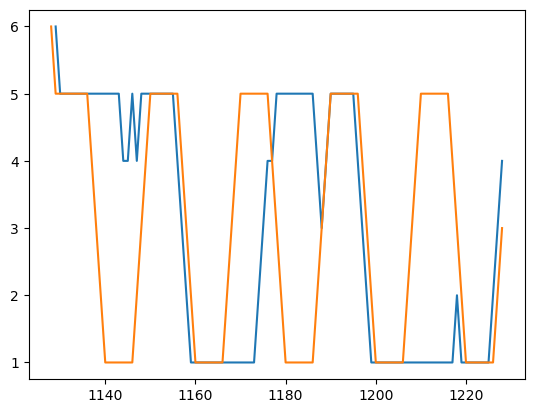

256 train done
0.5011898225904818


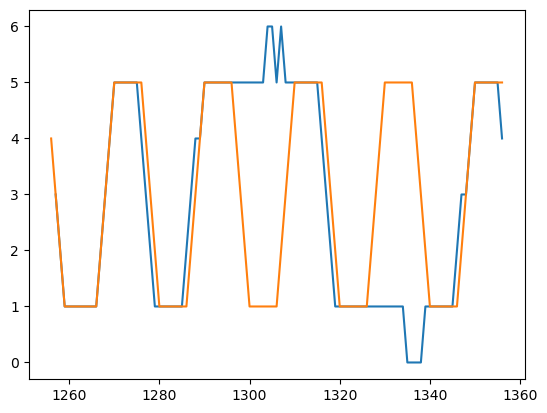

512 train done
0.24218045356779158


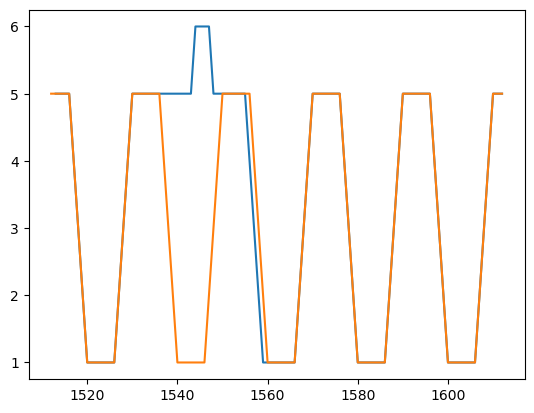

750 train done
0.5238104486960665


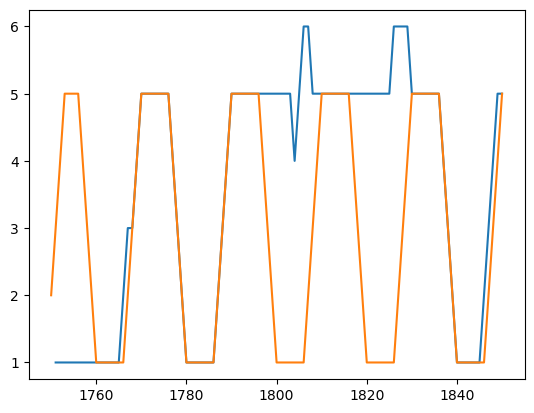

1024 train done
0.026436132757272048


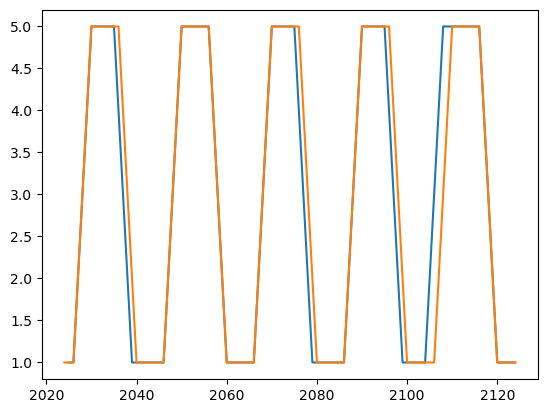

1250 train done
0.011809800000000053


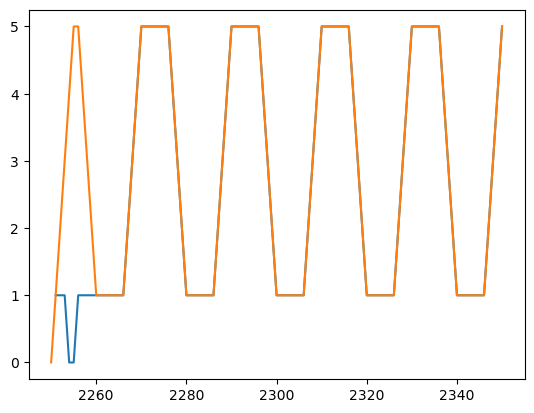

1500 train done
0.15468748927541554


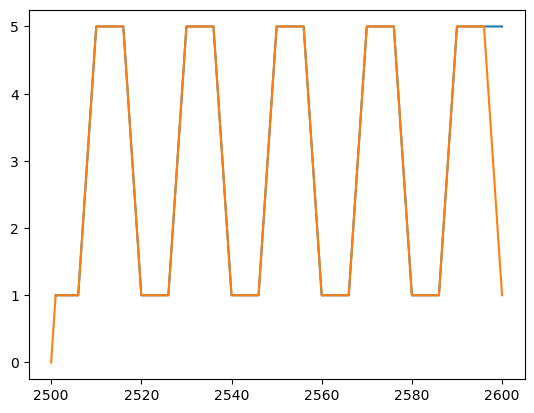

2048 train done
0.0


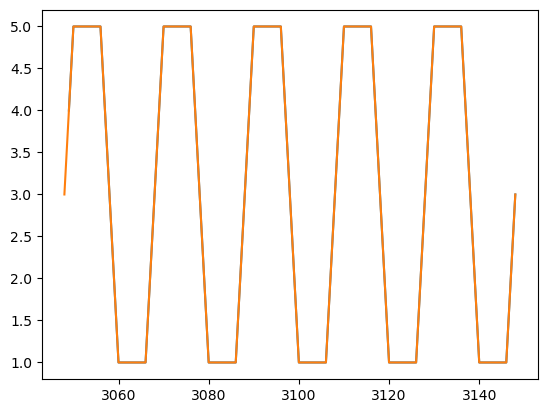

128 train done
0.8181855835374424


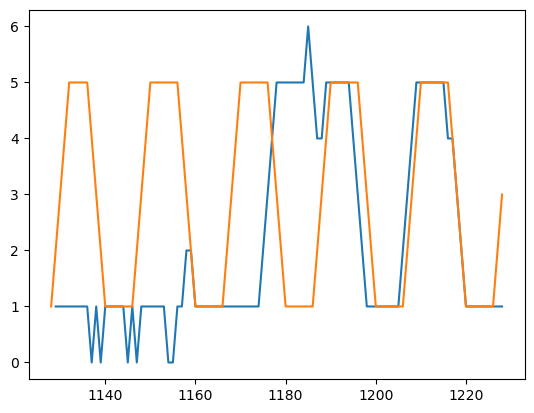

256 train done
0.2602125237874981


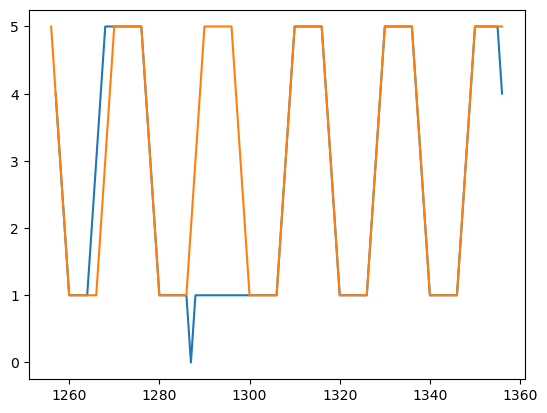

512 train done
0.250927987414172


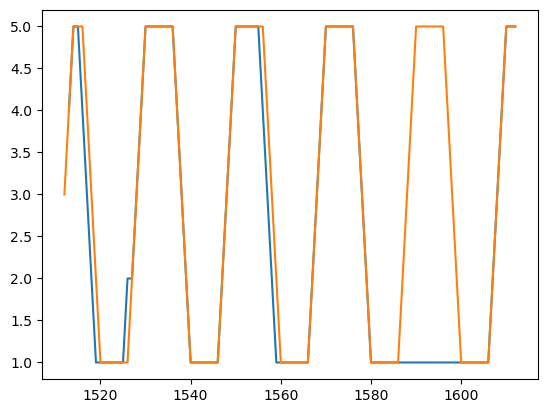

750 train done
0.27686465439979685


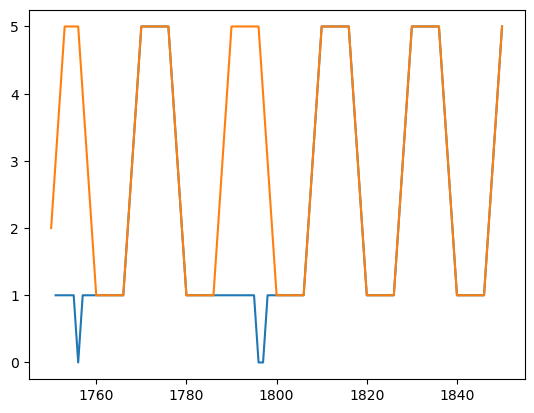

1024 train done
0.0


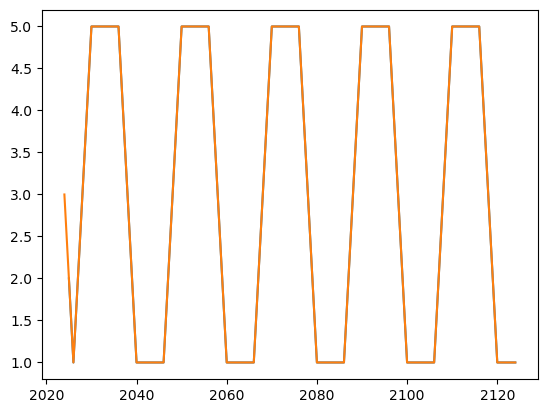

1250 train done
0.0231498000000002


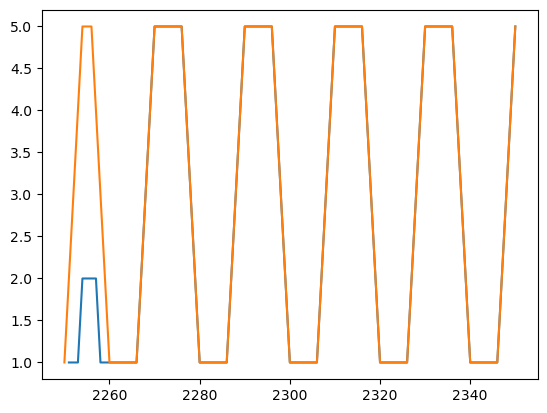

1500 train done
0.2518621161640624


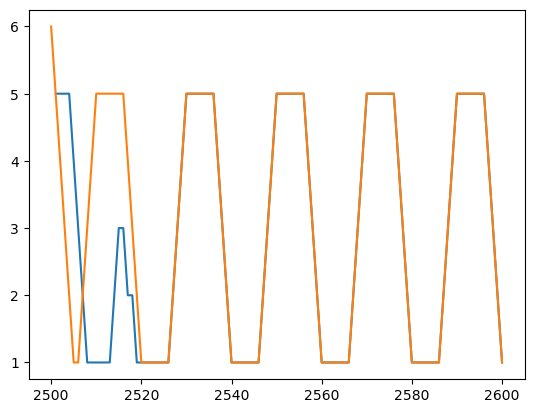

2048 train done
0.11695949999999983


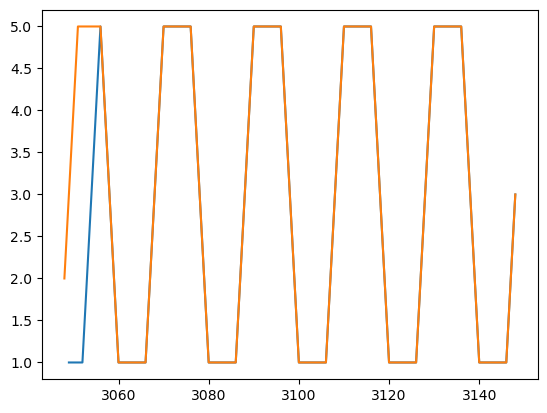

128 train done
0.7874422986551053


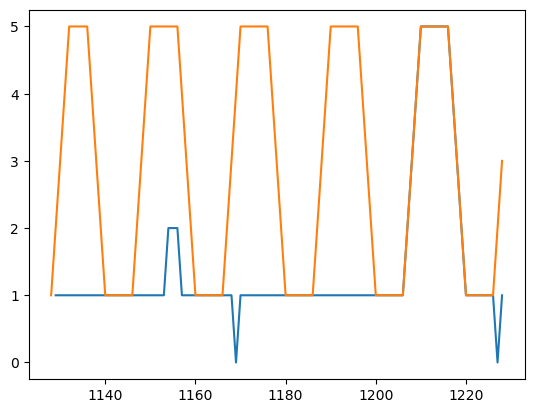

256 train done
0.9273925342641394


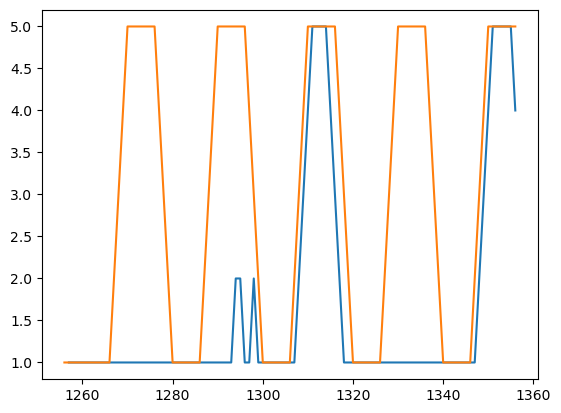

512 train done
0.3058151463729496


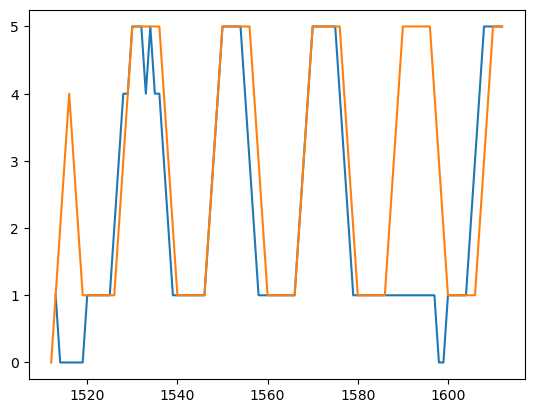

750 train done
0.47502949575484765


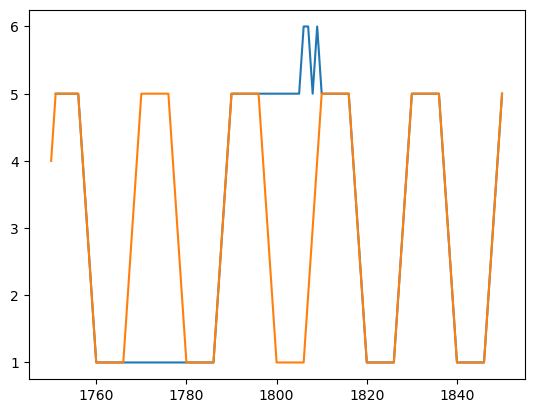

1024 train done
0.01866620706160262


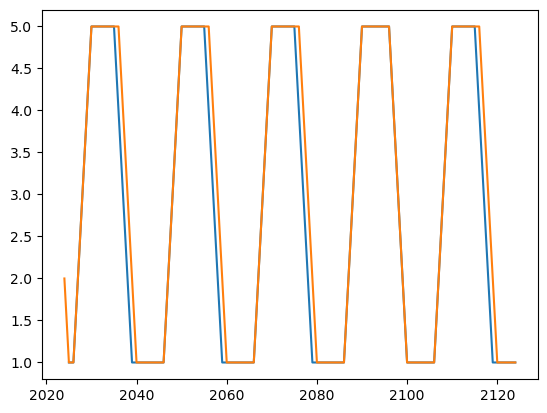

1250 train done
0.0


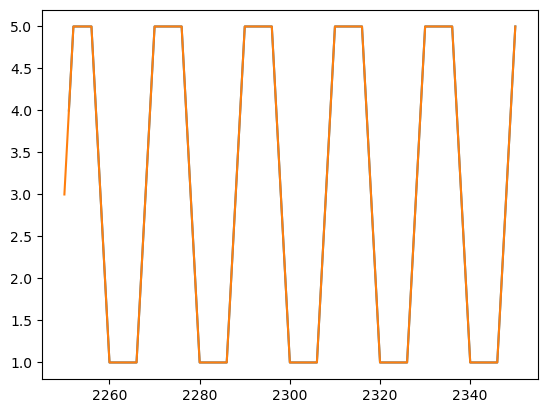

1500 train done
0.0


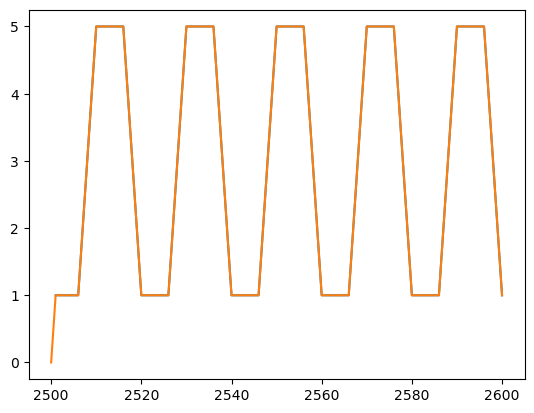

2048 train done
0.10930499999999994


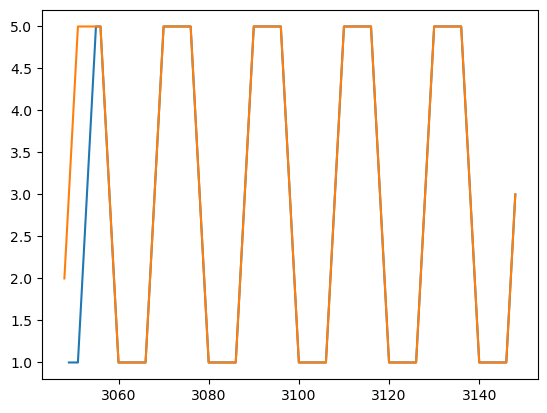

128 train done
0.6398799944716137


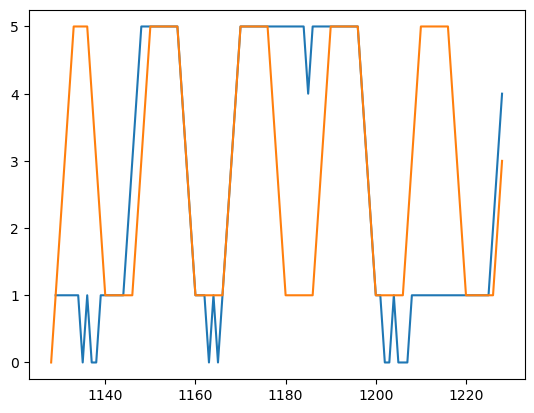

256 train done
0.023320397978311008


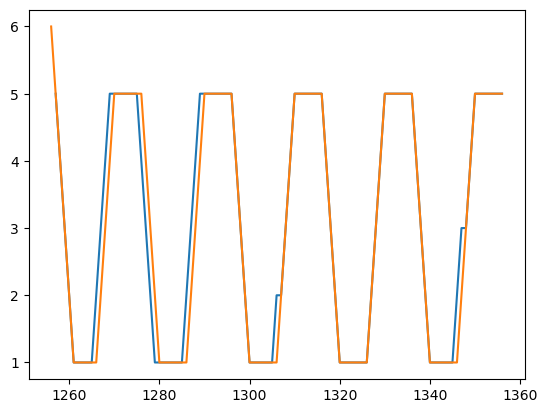

512 train done
0.2375148544000976


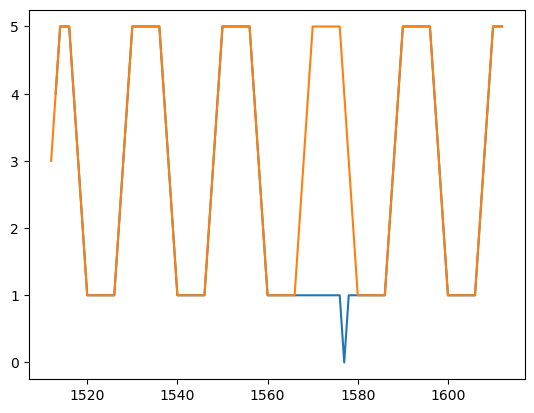

750 train done
0.4876532913549556


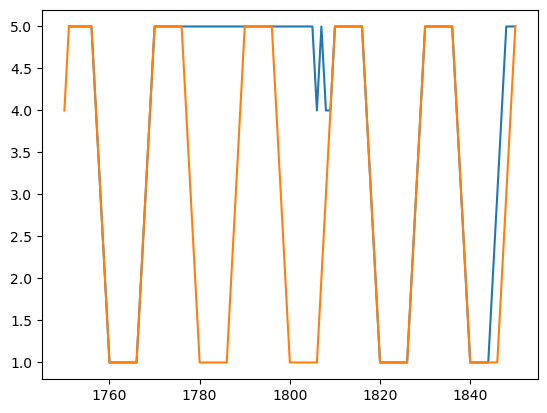

1024 train done
0.23754112338014693


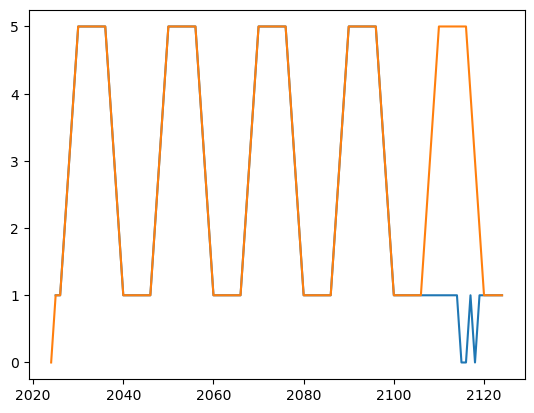

1250 train done
0.03934979999999996


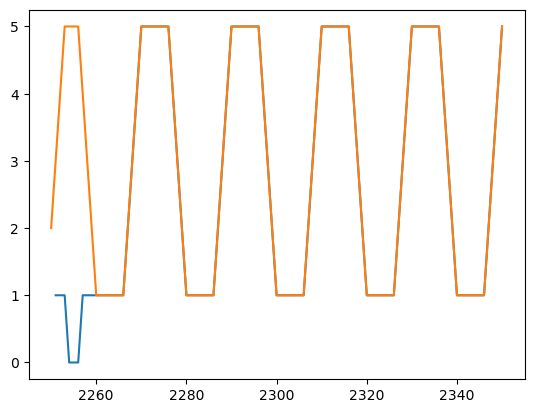

1500 train done
0.0


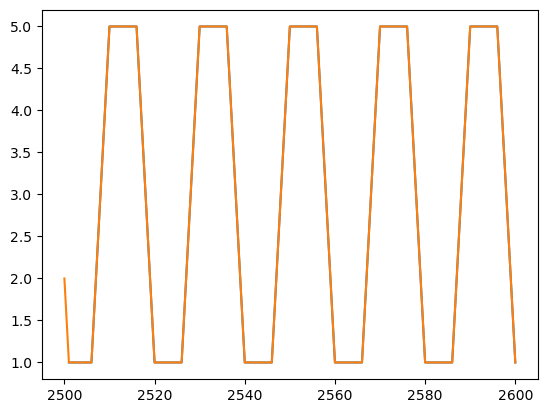

2048 train done
0.0


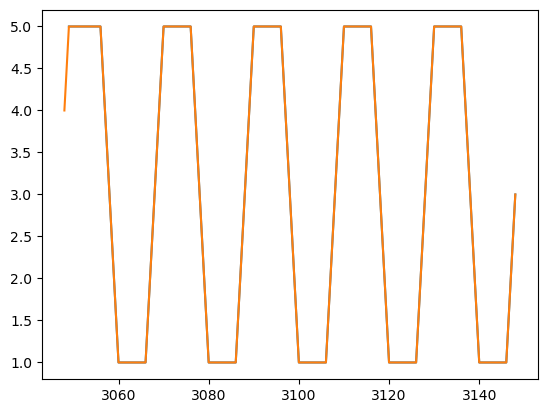

128 train done
0.4828950929086372


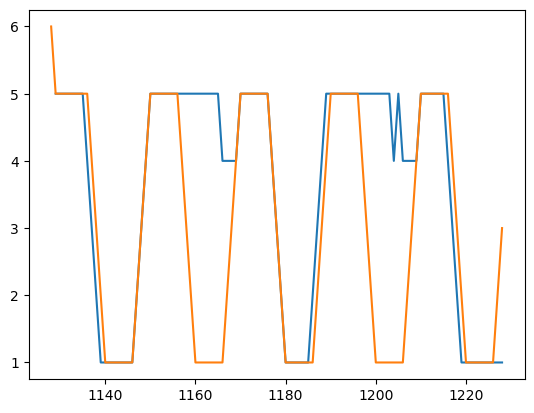

256 train done
0.9599207299116651


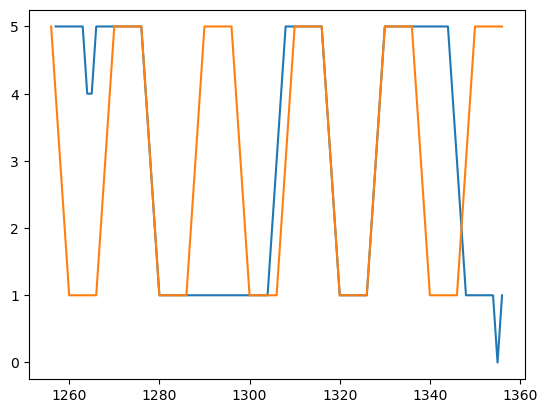

512 train done
0.25559350804237796


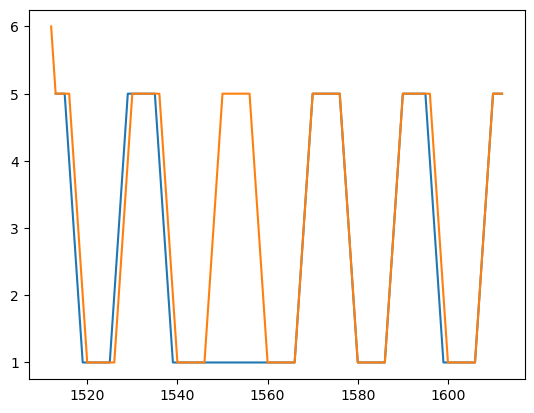

750 train done
0.00933119999999974


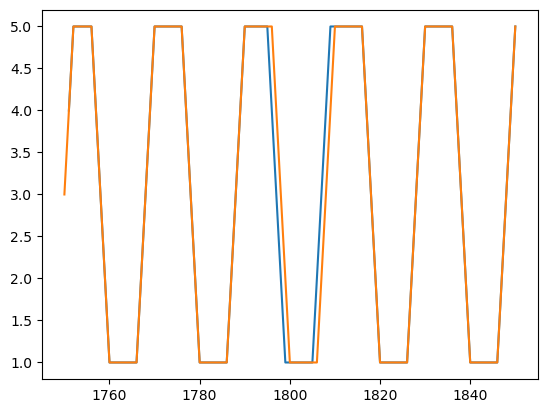

1024 train done
0.23751485107116935


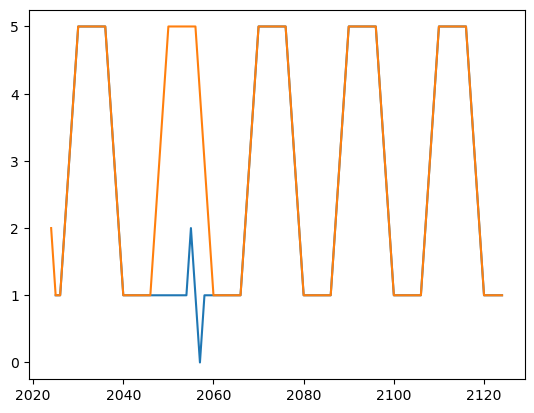

1250 train done
0.014096539588196606


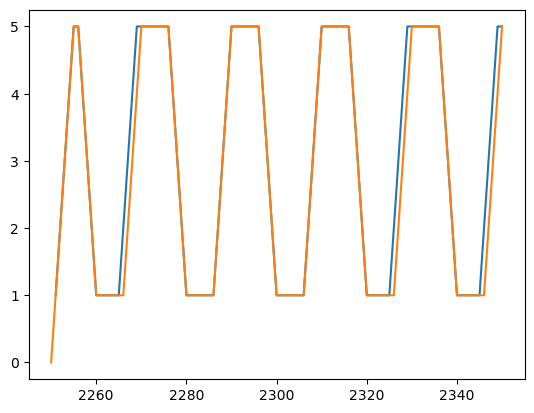

1500 train done
0.0072899999999998496


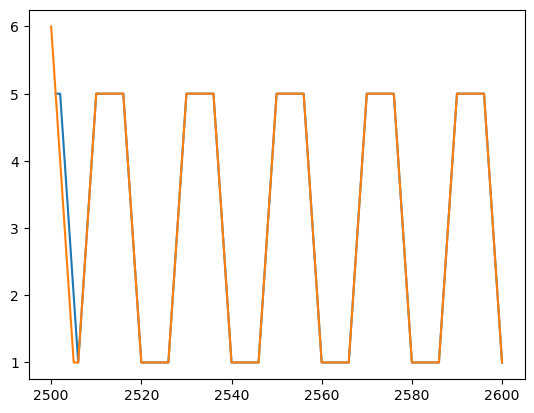

2048 train done
0.02025000000000034


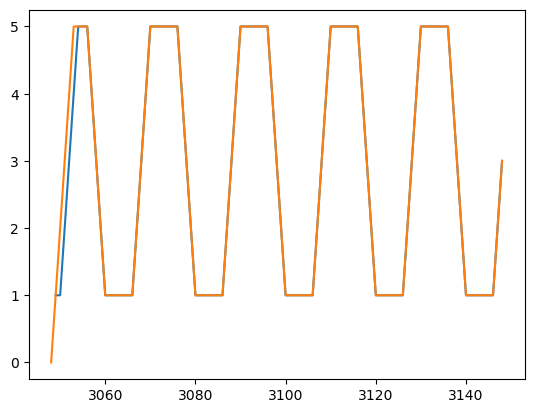

128 train done
0.5247855995557182


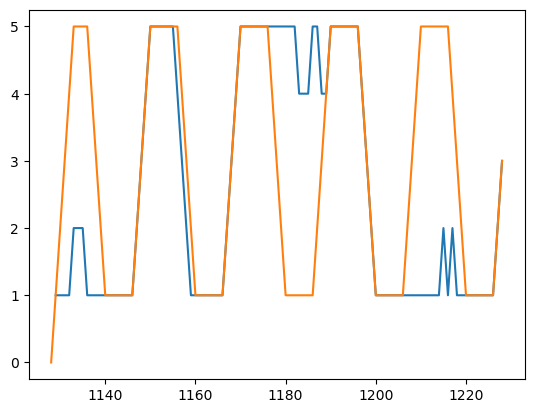

256 train done
0.49774218565856104


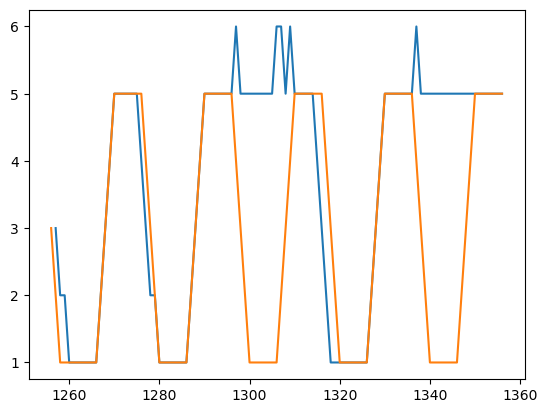

512 train done
0.25383255943811717


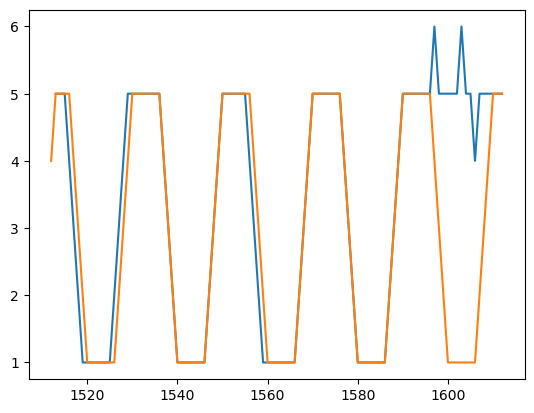

750 train done
0.24228074646318845


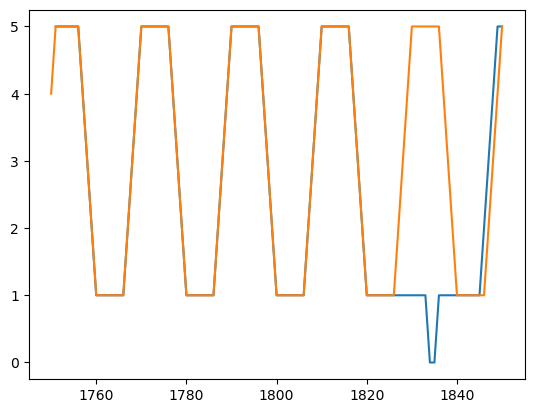

1024 train done
0.23751485442503564


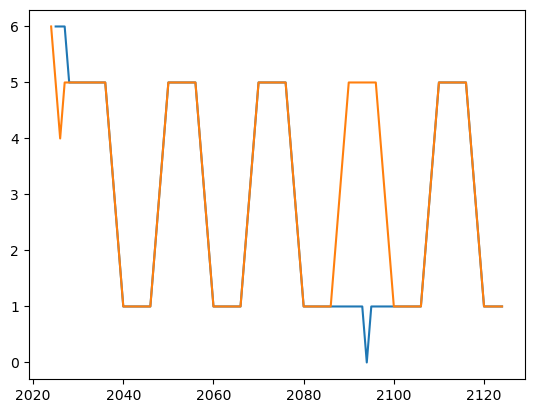

1250 train done
0.0


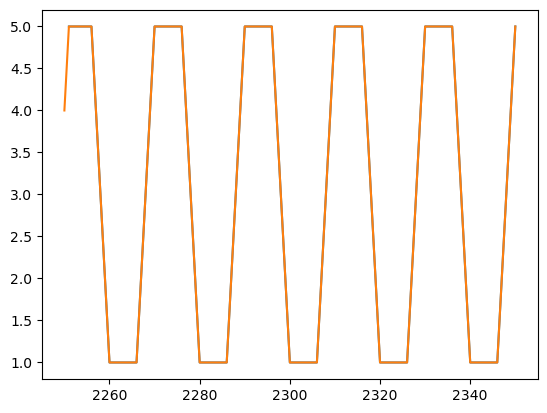

1500 train done
0.23284925440030066


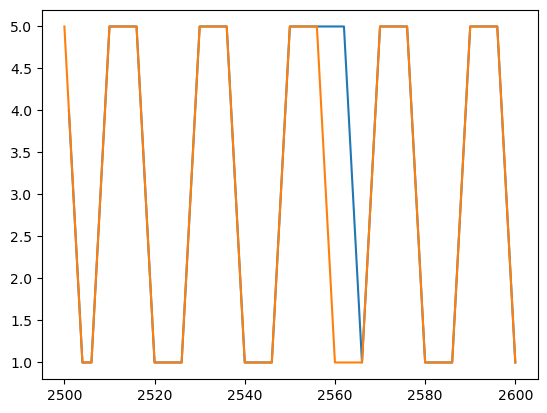

2048 train done
0.0


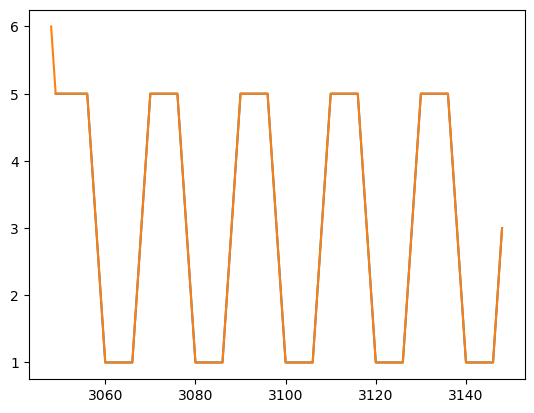

128 train done
1.2137345659619385


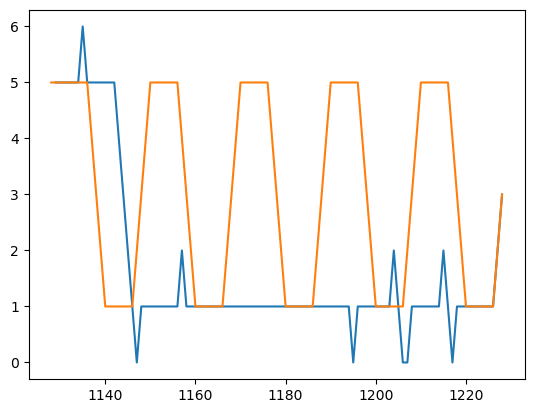

256 train done
0.5001515082032347


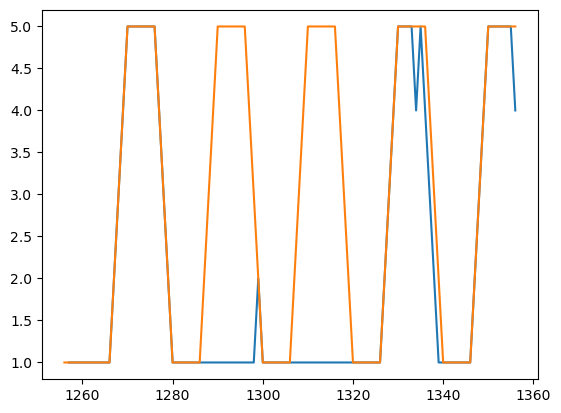

512 train done
0.2556185178627365


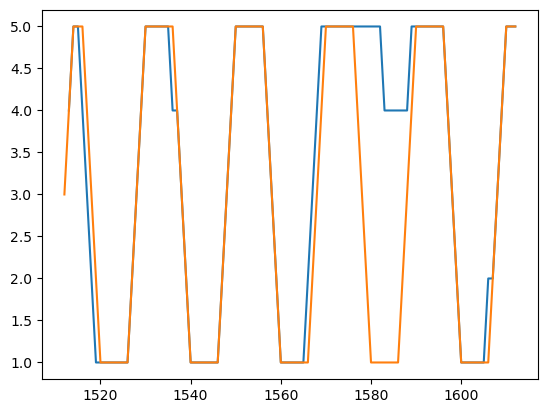

750 train done
0.24218045426095386


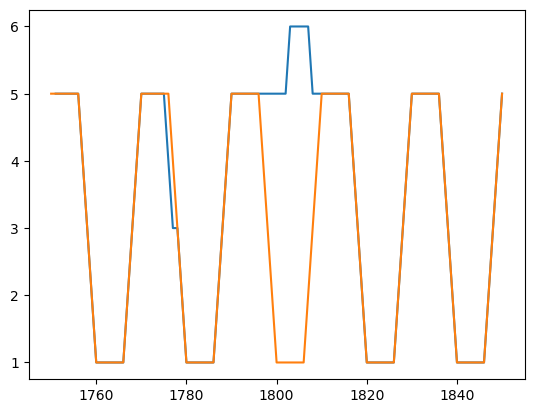

1024 train done
0.7160297596955797


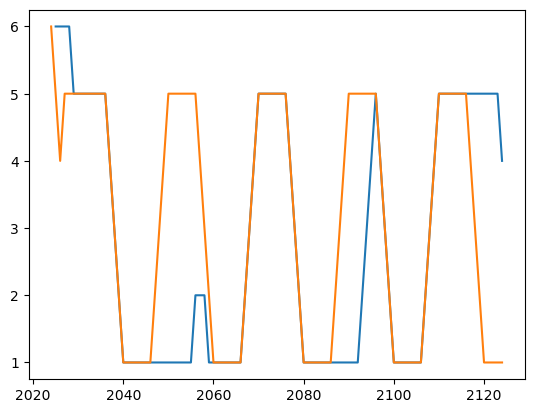

1250 train done
0.23751464135484782


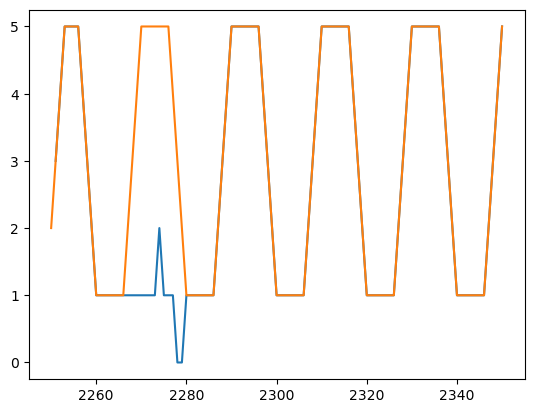

1500 train done
0.0


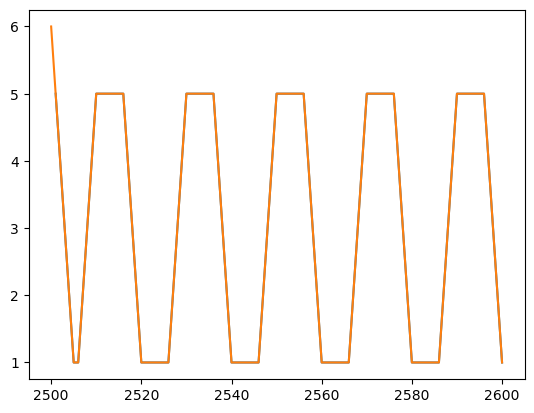

2048 train done
0.02025000000000034


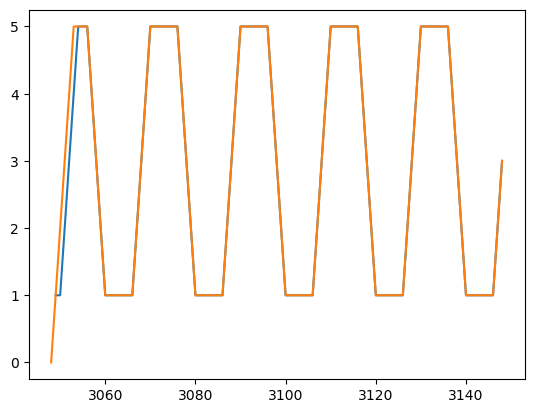

128 train done
0.7408890438217753


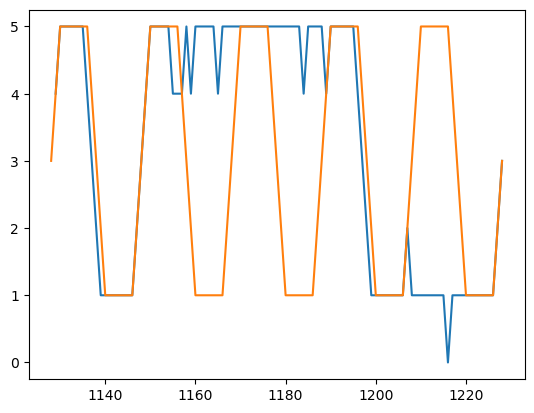

256 train done
0.7200095113740994


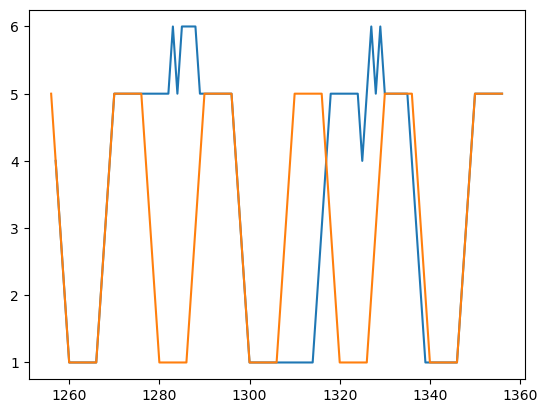

512 train done
0.48751619248146255


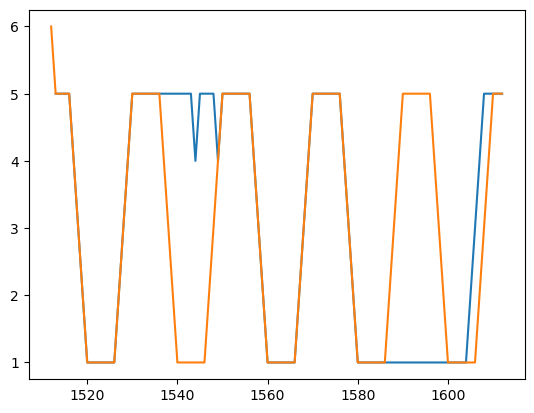

750 train done
0.8548628592318388


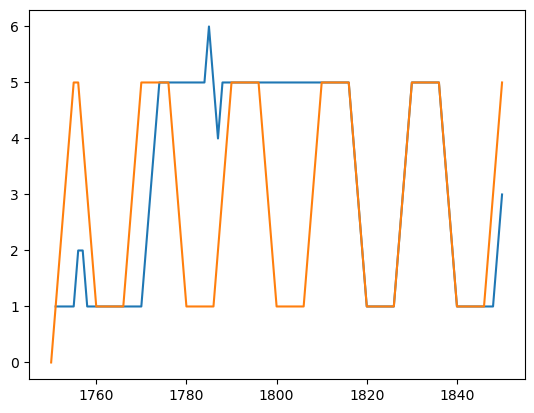

1024 train done
0.23751485439674924


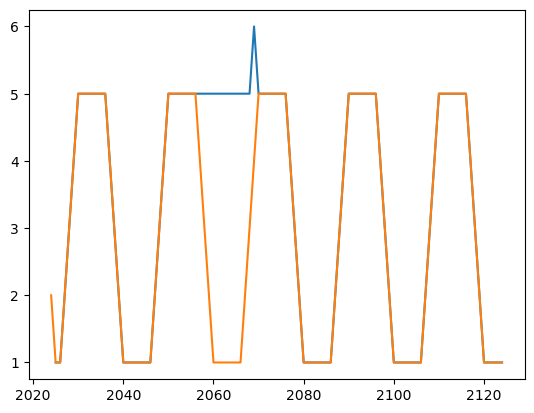

1250 train done
0.15468748927541554


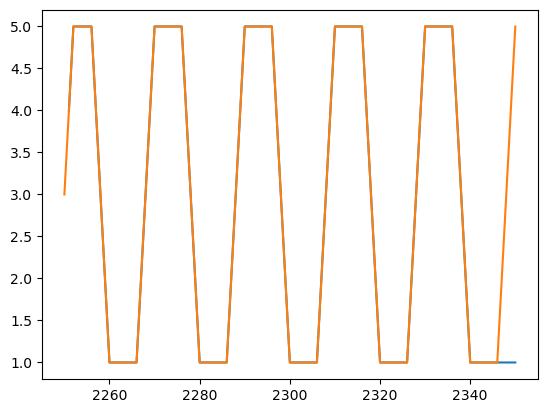

1500 train done
0.03482999999999976


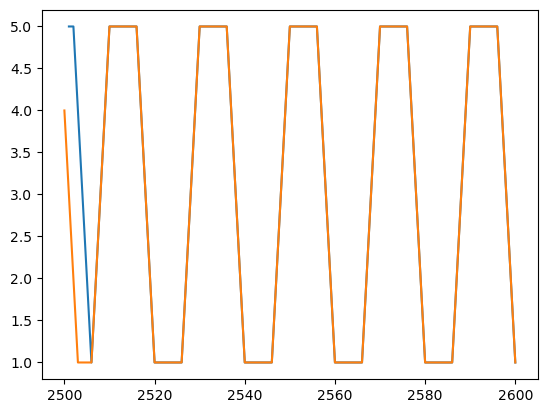

2048 train done
0.051750000000000115


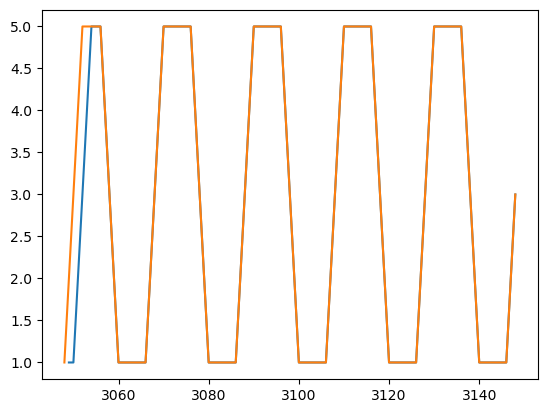

128 train done
0.49645534520386436


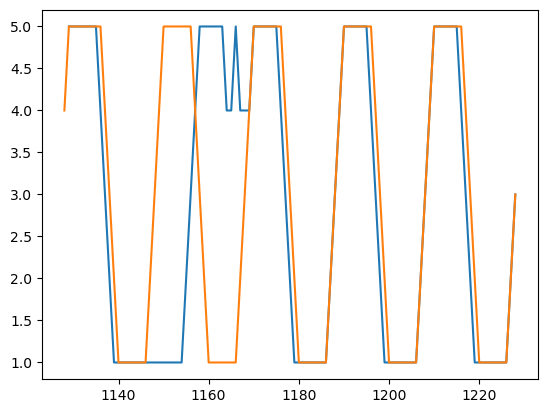

256 train done
0.7125511271839591


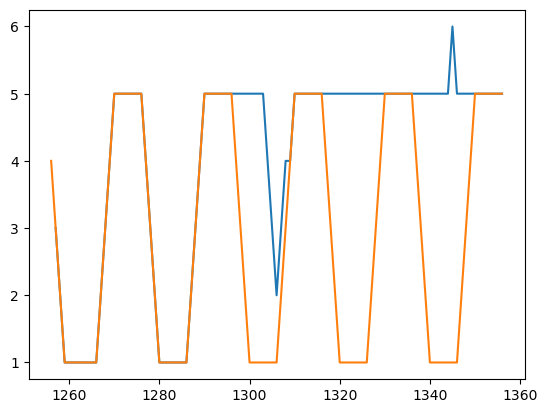

512 train done
0.707111616348758


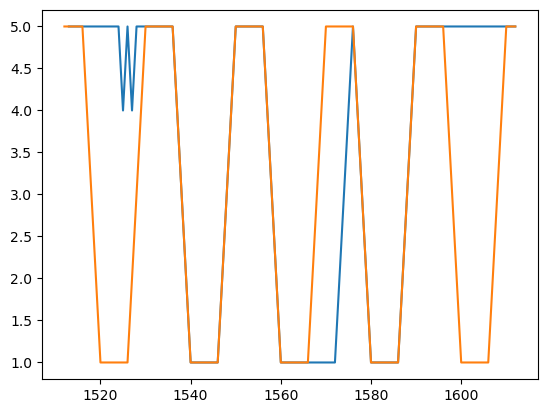

750 train done
0.18250288913637036


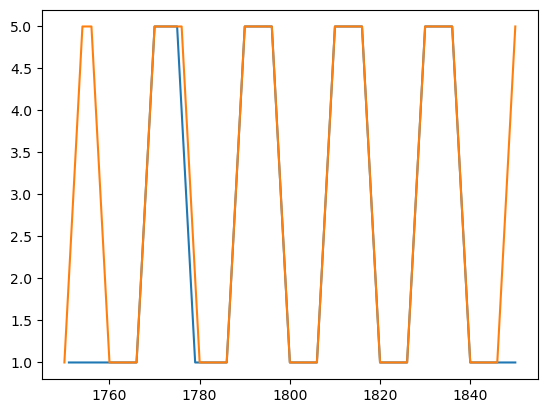

1024 train done
0.23402432262499986


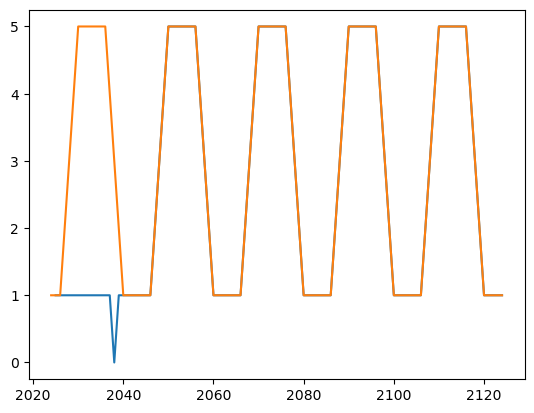

1250 train done
0.004665599999999586


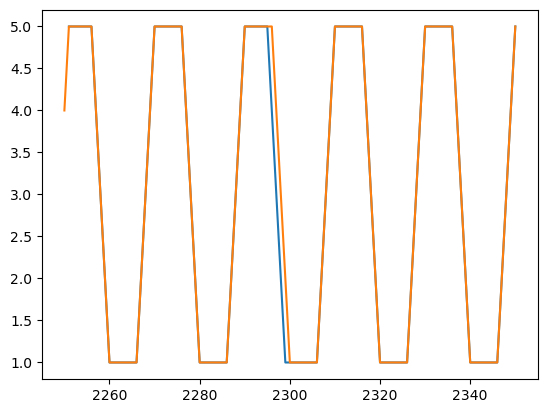

1500 train done
0.0046655999998642984


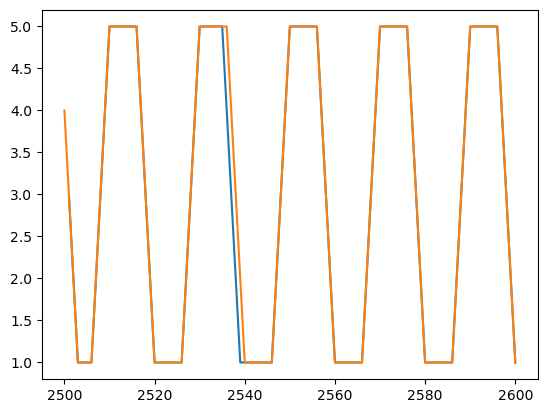

2048 train done
0.0


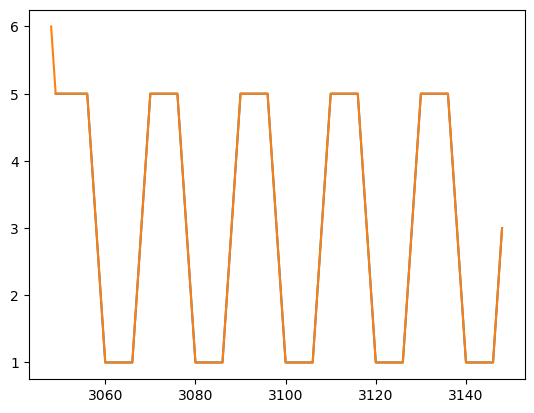

128 train done
0.47969525553867925


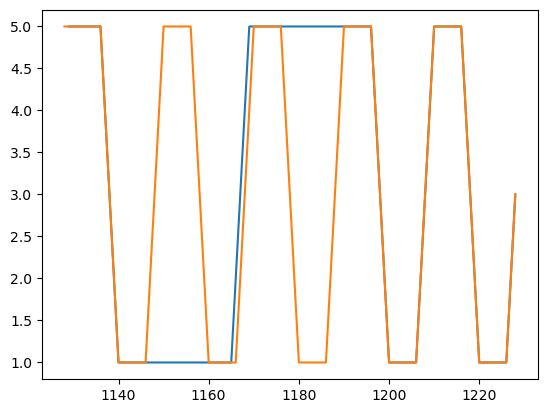

256 train done
0.264751338405712


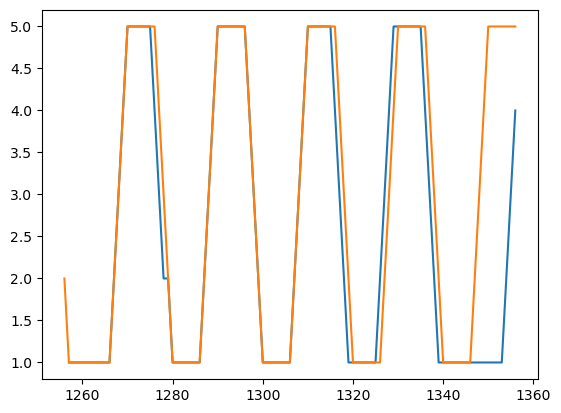

512 train done
0.4759897868512155


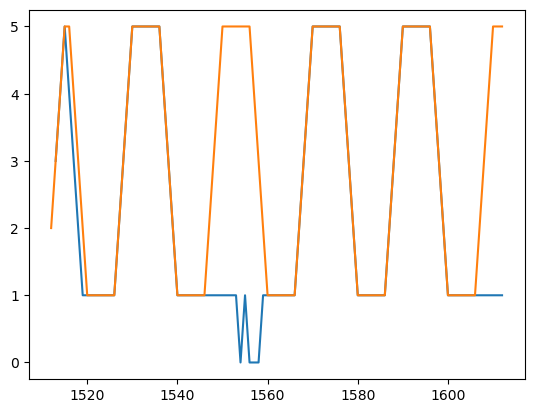

750 train done
0.2375148541919478


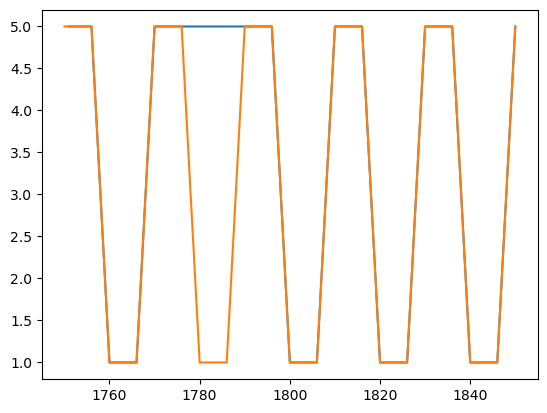

1024 train done
0.004665599999997596


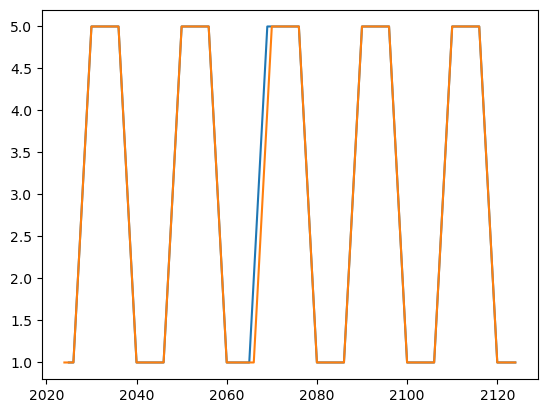

1250 train done
0.0


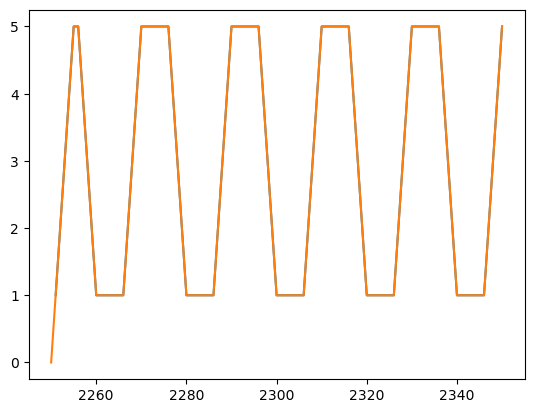

1500 train done
0.0072899999999998496


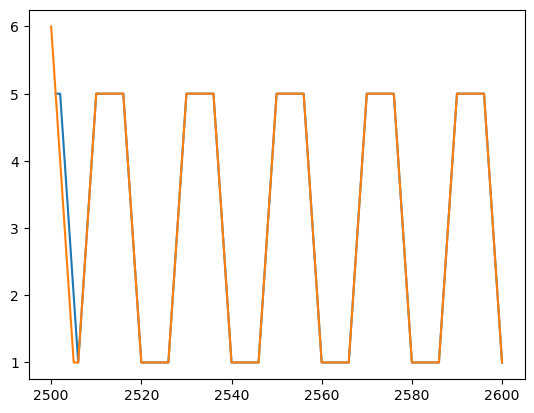

2048 train done
0.0


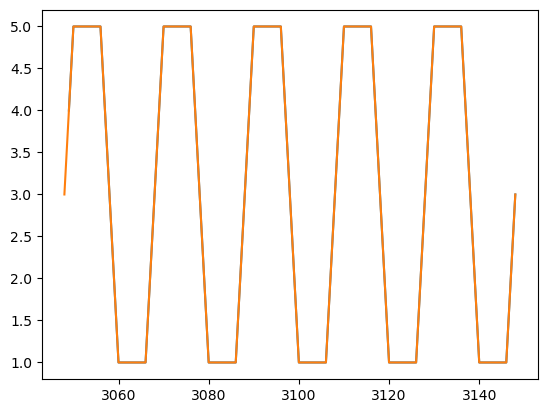

In [ ]:
gamma = 0.5 
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
## Onehot Encoding
Ts = [128,256,512]+[750]+[1024,1250,1500,2048]

for rep in range(10):
    for t_prime in [7]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515 + rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
            X_train = new_state_oh[:T,:]
            Y_train = irewards[:T]
            rf = MLPRegressor(
        hidden_layer_sizes=(128, 128),  #  MLP Layer structure
        solver='adam',
        learning_rate_init=1e-2,
        max_iter=5000,
        random_state=42,
        early_stopping=False,           
        verbose=False
                )
            rf.fit(X_train, Y_train)
            print(T-1000,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf.predict(features)

                # # Compute instantaneous rewards
                # for i, row in df_all_paths.iterrows():
                #     for t in np.arange(t_prime+1):
                #         cand = row[f"t={T+delta_t+t}"]
                #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
                #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
                #         irewards_pred[i, t] = rf.predict(features)[0]

                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                # Extract rewards from second column onward (t=1 to t=T)
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(1, t_prime+1)

                # Compute discounted total reward per path
                discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            #print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../result_PAFM_revised/One_hot/NN_onehot_w_lookahead_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )


25
(150, 57) (150,)
128 train done


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_12964\2631794607.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.959141196611296


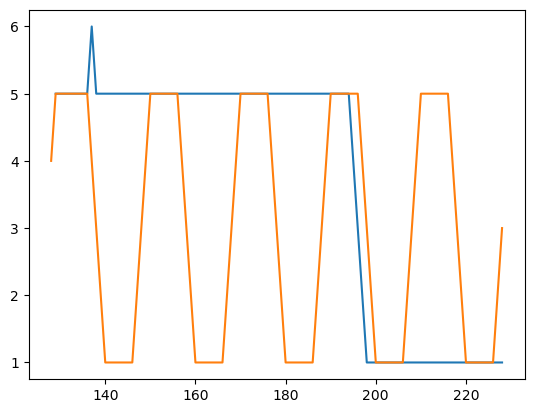

51
(306, 57) (306,)
256 train done


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_12964\2631794607.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.1946278294137542


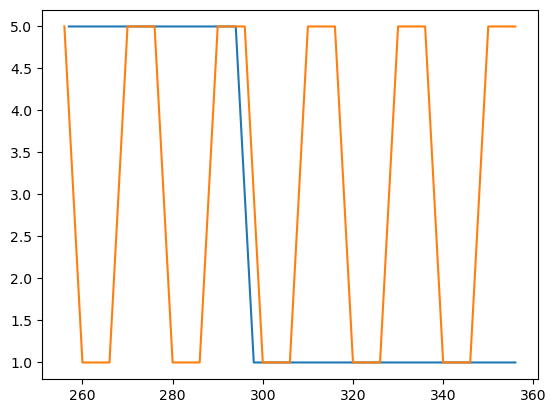

102
(612, 57) (612,)
512 train done


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_12964\2631794607.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.9548294515342832


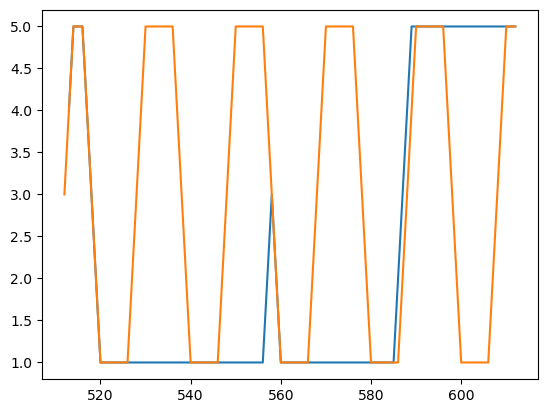

350
(2100, 57) (2100,)
1750 train done


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_12964\2631794607.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0231498000000002


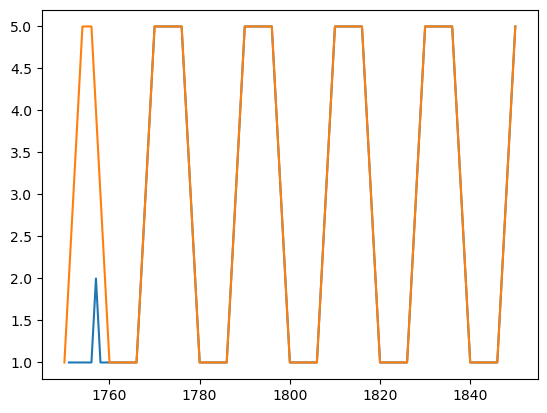

404
(2424, 57) (2424,)
2024 train done


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_12964\2631794607.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


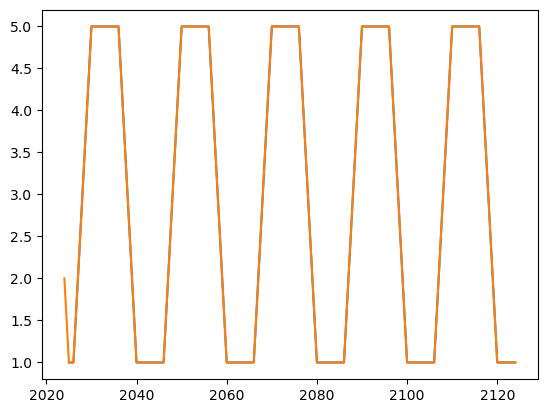

450
(2700, 57) (2700,)
2250 train done
0.0


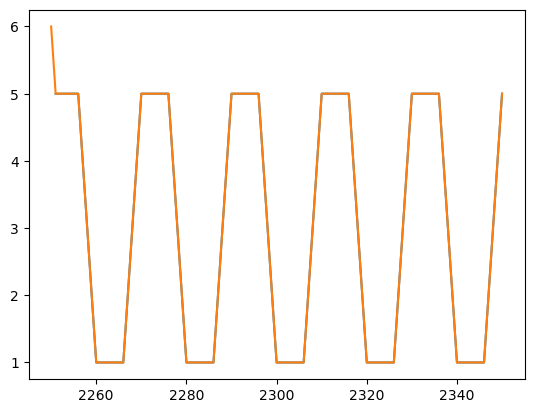

500
(3000, 57) (3000,)
2500 train done
0.011809800000000053


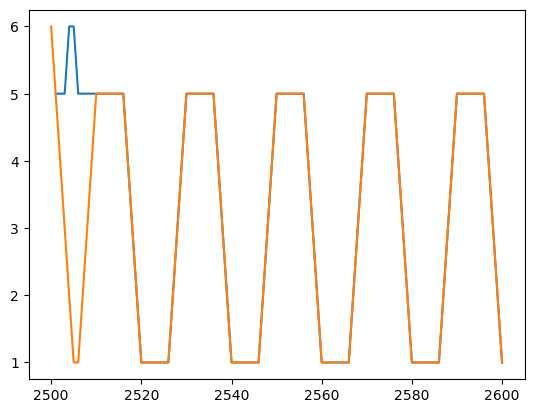

609
(3654, 57) (3654,)
3048 train done


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_12964\2631794607.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


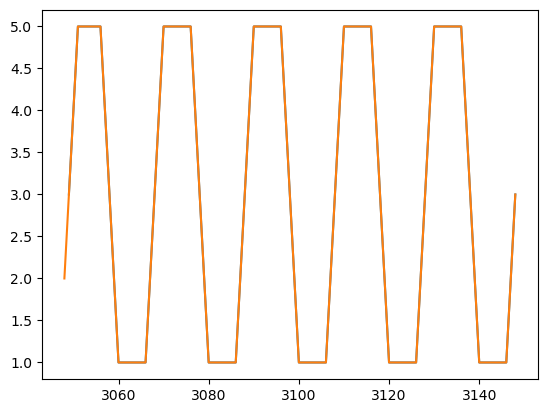

In [ ]:
#Oracle
DELTA_t = 5
t_prime = 7
FUTURE_STATE = []
for T in Ts:
    n_seq = int(T/DELTA_t)
    # n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards,gamma = 0.5))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe)
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    # plt.plot(opt_times[0],opt_paths[0])
    # plt.show()
    # plt.plot(opt_times[0],opt_irewards[0])
    # plt.show()
    X_train = STATES_arr
    Y_train = REWARDS_arr
    rf = rf = MLPRegressor(
    hidden_layer_sizes=(128, 128),  
    solver='adam',
    learning_rate_init=1e-2,
    max_iter=5000,
    random_state=42,
    early_stopping=False,           
    verbose=False
            )
    rf.fit(X_train, Y_train)
    print(T,'train done')

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        irewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            irewards_pred[:,i] = rf.predict(features)
        reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
        df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
        rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
        discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
        discounted_returns = rewards_matrix * discounts  
        total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
        bext_idx = np.argmax(total_discounted)
        next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
        future_states.append(next_state)
        current_state = next_state
    
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"E:../result_PAFM/Oracle/NN_oracle_w_lookahead_reps{9}.npz",
    future_states =FUTURE_STATE_arr
    )